## Base Case Repayment Simulation

In [1]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, SalaryGrowthType, salary_growth_amounts
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel
import numpy as np 
import pandas as pd

- for the base case look at how the loan balance changes based upon the mandatory repayments
- after this we can see how changing the growth types affects the base case

In [3]:
n_paths = 10_000
years_remaining = 30
seed = 1234
starting_salary = 35_000
initial_loan = 45_000
salary_growth = SalaryGrowthType(growth_type="Medium")

In [5]:
salary_config=SalaryModelInputs(
    starting_salary=starting_salary,
    salary_growth_dist=salary_growth
)
loan_config = LoanModelInputs(
    initial_loan_balance=initial_loan,
    remaining_loan_term_months=12*years_remaining
)
rng = np.random.default_rng(seed)
salary_model = SalaryModel(salary_config, rng)
loan_model = LoanModel(loan_config)
salary_paths = salary_model.generate_salary_paths(n_paths=n_paths, n_months=years_remaining * 12)
loan_result = loan_model.generate_loan_paths(salary_paths=salary_paths)

In [13]:
np.mean(loan_result.loan_balance[:, -1], axis=0)

np.float64(30944.46437903942)

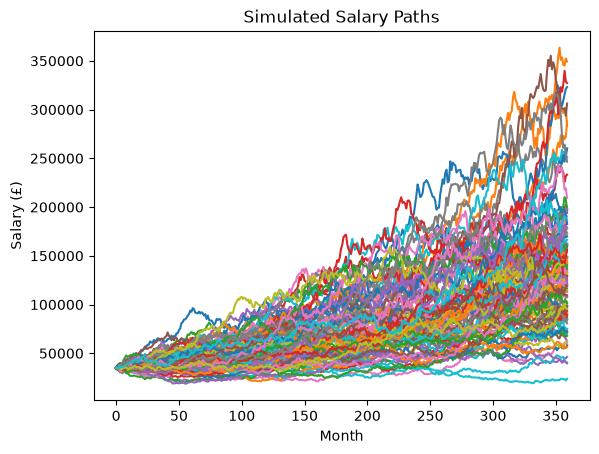

In [14]:
import matplotlib.pyplot as plt

for path in salary_paths[:100]:
    plt.plot(path)

plt.xlabel("Month")
plt.ylabel("Salary (£)")
plt.title("Simulated Salary Paths")
plt.show()

In [17]:
p10 = np.percentile(salary_paths, 10, axis=0)
p50 = np.percentile(salary_paths, 50, axis=0)
p90 = np.percentile(salary_paths, 90, axis=0)
# print(p10, p50, p90)

In [19]:
final_loan_balance = loan_result.loan_balance[:, -1]
total_interest = loan_result.interest_accrued.sum(axis=1)
total_repayments = loan_result.base_repayment.sum(axis=1)
pd.DataFrame({
    "Final Loan Balance": final_loan_balance,
    "Total Interest": total_interest,
    "Total Repayments": total_repayments,
}).describe()

,Final Loan Balance,Total Interest,Total Repayments
count,10000.000000,10000.000000,10000.000000
mean,30944.464379,71811.001457,136020.440248
std,38882.213901,22401.402793,83049.745252
min,0.000000,21129.742863,448.338090
25%,0.000000,52012.314141,76628.201533
50%,0.000000,73160.465454,119272.560725
75%,64931.209091,93210.224931,177967.089646
max,114523.652679,107342.090743,729984.336684


In [20]:
loan_repaid = np.any(loan_result.loan_balance == 0, axis=1)

probability_repaid = loan_repaid.mean()

In [21]:
probability_repaid

np.float64(0.5054)

In [23]:
repaid = np.any(loan_result.loan_balance == 0, axis=1)

repayment_month = np.full(n_paths, np.nan)

repayment_month[repaid] = np.argmax(
    loan_result.loan_balance[repaid] == 0,
    axis=1,
)

repayment_year = repayment_month / 12

In [24]:
np.nanmedian(repayment_year)
np.nanpercentile(repayment_year, [10, 25, 50, 75, 90])

array([17.08333333, 19.6875    , 23.        , 26.33333333, 28.39166667])

- now look how changing the salary growth types changes the outcomes

In [25]:
results = {}

for growth_type in salary_growth_amounts:
    rng_gen = np.random.default_rng(seed)

    salary_config = SalaryModelInputs(
        starting_salary=starting_salary,
        salary_growth_dist=SalaryGrowthType(growth_type=growth_type),
    )

    salary_model = SalaryModel(
        config=salary_config,
        rng_gen=rng_gen,
    )

    salary_paths = salary_model.generate_salary_paths(
        n_paths=n_paths,
        n_months=years_remaining * 12,
    )

    loan_result = loan_model.generate_loan_paths(
        salary_paths,
    )

    results[growth_type] = {
        "salary_paths": salary_paths,
        "loan_result": loan_result,
    }

In [30]:
metric_panel = []

for growth_type, result in results.items():

    salary_paths = result["salary_paths"]
    loan_result = result["loan_result"]

    final_salary = salary_paths[:, -1]
    final_loan_balance = loan_result.loan_balance[:, -1]

    total_interest = loan_result.interest_accrued.sum(axis=1)
    total_repayments = loan_result.base_repayment.sum(axis=1)

    loan_repaid = np.any(
        loan_result.loan_balance == 0,
        axis=1,
    )

    repayment_month = np.full(n_paths, np.nan)

    repayment_month[loan_repaid] = np.argmax(
        loan_result.loan_balance[loan_repaid] == 0,
        axis=1,
    )

    repayment_year = repayment_month / 12

    metric_panel.append({
        "Growth Type": growth_type,
        "Median Final Salary": np.median(final_salary),
        "Median Final Loan": np.median(final_loan_balance),
        "Mean Final Loan": np.mean(final_loan_balance),
        "Probability Repaid": loan_repaid.mean(),
        "Median Payoff Year": np.nanmedian(repayment_year),
        "Median Total Interest": np.median(total_interest),
        "Median Total Repayments": np.median(total_repayments),
    })


metric_panel = pd.DataFrame(metric_panel)

metric_panel

,Growth Type,Median Final Salary,Median Final Loan,Mean Final Loan,Probability Repaid,Median Payoff Year,Median Total Interest,Median Total Repayments
0,Low,45775.805751,106241.6016,103531.616331,0.0003,28.250000,91077.603439,29204.053702
1,Medium,131847.937888,0.0000,30944.464379,0.5054,23.000000,73160.465454,119272.560725
2,High,498102.311440,0.0000,1347.578866,0.9686,16.833333,37028.769938,394776.200107


In [31]:
display_panel = metric_panel.copy()

display_panel["Median Final Salary"] = (
    display_panel["Median Final Salary"]
    .map(lambda x: f"£{x:,.0f}")
)

display_panel["Median Final Loan"] = (
    display_panel["Median Final Loan"]
    .map(lambda x: f"£{x:,.0f}")
)

display_panel["Mean Final Loan"] = (
    display_panel["Mean Final Loan"]
    .map(lambda x: f"£{x:,.0f}")
)

display_panel["Probability Repaid"] = (
    display_panel["Probability Repaid"]
    .map(lambda x: f"{x:.1%}")
)

display_panel["Median Payoff Year"] = (
    display_panel["Median Payoff Year"]
    .map(lambda x: f"{x:.1f}")
)

display_panel["Median Total Interest"] = (
    display_panel["Median Total Interest"]
    .map(lambda x: f"£{x:,.0f}")
)

display_panel["Median Total Repayments"] = (
    display_panel["Median Total Repayments"]
    .map(lambda x: f"£{x:,.0f}")
)

display_panel

,Growth Type,Median Final Salary,Median Final Loan,Mean Final Loan,Probability Repaid,Median Payoff Year,Median Total Interest,Median Total Repayments
0,Low,"£45,776","£106,242","£103,532",0.0%,28.2,"£91,078","£29,204"
1,Medium,"£131,848",£0,"£30,944",50.5%,23.0,"£73,160","£119,273"
2,High,"£498,102",£0,"£1,348",96.9%,16.8,"£37,029","£394,776"
